In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from miss_alignment.data.shift_generation import JitterGenerator, OutlierGenerator, TrajectoryGenerator, FractureGenerator

sns.set(context='talk', style='ticks')

In [3]:
# Setup for shift visualization
n_tilts_plot = 35
tilt_angles_plot = np.linspace(-51, 51, n_tilts_plot)

## Reconstructions with Different Shift Types

In this section, we load a tilt-series and create reconstructions at a specific 3D position with different types of shifts applied.

In [4]:
import torch
from pathlib import Path
from miss_alignment.data.io import TiltSeriesData
from miss_alignment.data.shift_generation import project_shifts_3d_to_2d
from torch_affine_utils.transforms_3d import Ry, Rz
from warpylib.tilt_series.reconstruct_volume import preprocess_tilt_data

# Load tilt-series data
json_path = Path("/home/marten/data/download/shrec_zenodo/ground_truth/model_1.json") 
tilt_series_data = TiltSeriesData.from_json(json_path)
tilt_series, images, pixel_size = tilt_series_data.load_metadata_and_stack(downsample=1)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
tilt_series = tilt_series.to(device)
images = images.to(device)

# Preprocess images
patch_size = 96
images = preprocess_tilt_data(
    tilt_data=images,
    normalize=True,
    invert=False,
    subvolume_size=patch_size,
)

# Select a 3D position for reconstruction (center of volume by default)
x_dim, y_dim, z_dim = tilt_series.volume_dimensions_physical
reconstruction_location = torch.tensor([[x_dim/2, y_dim/2, z_dim/2]], device=device)

print(f"Loaded tilt-series with {len(tilt_series.angles)} images")
print(f"Pixel size: {pixel_size:.2f} Å")
print(f"Volume dimensions: {x_dim:.0f} x {y_dim:.0f} x {z_dim:.0f} Å")
print(f"Reconstruction location: {reconstruction_location[0].cpu().numpy()}")

Loaded tilt-series with 61 images
Pixel size: 10.00 Å
Volume dimensions: 5120 x 5120 x 1800 Å
Reconstruction location: [2560. 2560.  900.]


In [9]:
# Setup for applying shifts
n_tilts = len(tilt_series.angles)

# Calculate projection matrices for 3D to 2D shift projection
r0 = Ry(-tilt_series.angles, zyx=True)
r1 = Rz(tilt_series.tilt_axis_angles, zyx=True)
rotation_matrices = r1 @ r0
projection_matrices = rotation_matrices[..., 1:3, :3]

# Store original alignment parameters
original_offset_x = tilt_series.tilt_axis_offset_x.clone()
original_offset_y = tilt_series.tilt_axis_offset_y.clone()

def apply_shifts_and_reconstruct(shift_generator, label):
    """Apply shifts from a generator and perform reconstruction."""
    # Reset to original alignment
    tilt_series.tilt_axis_offset_x = original_offset_x.clone()
    tilt_series.tilt_axis_offset_y = original_offset_y.clone()

    shifts_3d = None
    if shift_generator is not None:
        # Generate 3D shifts
        shifts_3d = shift_generator(n_tilts, device)

        # Project to 2D and convert to Angstroms
        shifts_2d = project_shifts_3d_to_2d(shifts_3d, projection_matrices)
        shifts_angstrom = shifts_2d * pixel_size

        # Apply shifts
        # tilt_series.tilt_axis_offset_y += shifts_angstrom[:, 0]
        tilt_series.tilt_axis_offset_x += shifts_angstrom[:, 1]

    # Perform reconstruction
    reconstruction = tilt_series.reconstruct_subvolumes_single(
        tilt_data=images,
        coords=reconstruction_location,
        pixel_size=pixel_size,
        size=patch_size,
        apply_ctf=False,
        angles=torch.tensor([0.0, 0.0, 0.0], device=device),
        oversampling=2.0,
    ).squeeze()

    print(f"Completed reconstruction: {label}")
    return reconstruction.cpu(), shifts_3d

# Perform reconstructions and store shifts
reconstructions = {}
shifts_dict = {}

# 1. No shifts (baseline)
reconstructions['No shifts'], shifts_dict['No shifts'] = apply_shifts_and_reconstruct(None, "No shifts")

# 2. Jitter only
reconstructions['Jitter'], shifts_dict['Jitter'] = apply_shifts_and_reconstruct(
    JitterGenerator(jitter_max_std=2.0), "Jitter"
)

# 3. Trajectory only
reconstructions['Trajectory'], shifts_dict['Trajectory'] = apply_shifts_and_reconstruct(
    TrajectoryGenerator(trajectory_max_shift=10.0), "Trajectory"
)

# 4. Outliers only
reconstructions['Outliers'], shifts_dict['Outliers'] = apply_shifts_and_reconstruct(
    OutlierGenerator(outlier_max_shift=20), "Outliers"
)

# 5. Fractures only
reconstructions['Fractures'], shifts_dict['Fractures'] = apply_shifts_and_reconstruct(
    FractureGenerator(fracture_max_shift=20), "Fractures"
)

# 6. Combined (all shift types) - sum the previously generated shifts
# Reset to original alignment
tilt_series.tilt_axis_offset_x = original_offset_x.clone()
tilt_series.tilt_axis_offset_y = original_offset_y.clone()

# Sum all the previously generated shifts
combined_shifts_3d = torch.zeros((n_tilts, 3), device=device)
combined_shifts_3d += shifts_dict['Jitter']
combined_shifts_3d += shifts_dict['Trajectory']
combined_shifts_3d += shifts_dict['Outliers']
combined_shifts_3d += shifts_dict['Fractures']

# Store the combined shifts
shifts_dict['Combined'] = combined_shifts_3d

# Project and apply
combined_shifts_2d = project_shifts_3d_to_2d(combined_shifts_3d, projection_matrices)
combined_shifts_angstrom = combined_shifts_2d * pixel_size
tilt_series.tilt_axis_offset_y += combined_shifts_angstrom[:, 0]
tilt_series.tilt_axis_offset_x += combined_shifts_angstrom[:, 1]

reconstructions['Combined'] = tilt_series.reconstruct_subvolumes_single(
    tilt_data=images,
    coords=reconstruction_location,
    pixel_size=pixel_size,
    size=patch_size,
    apply_ctf=False,
    angles=torch.tensor([0.0, 0.0, 0.0], device=device),
    oversampling=2.0,
).squeeze().cpu()

print("Completed reconstruction: Combined")

# Reset to original alignment
tilt_series.tilt_axis_offset_x = original_offset_x
tilt_series.tilt_axis_offset_y = original_offset_y

Completed reconstruction: No shifts
Completed reconstruction: Jitter
Completed reconstruction: Trajectory
Completed reconstruction: Outliers
Completed reconstruction: Fractures
Completed reconstruction: Combined


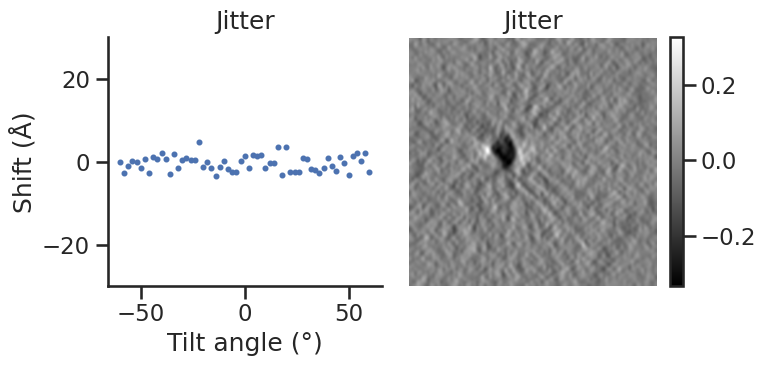

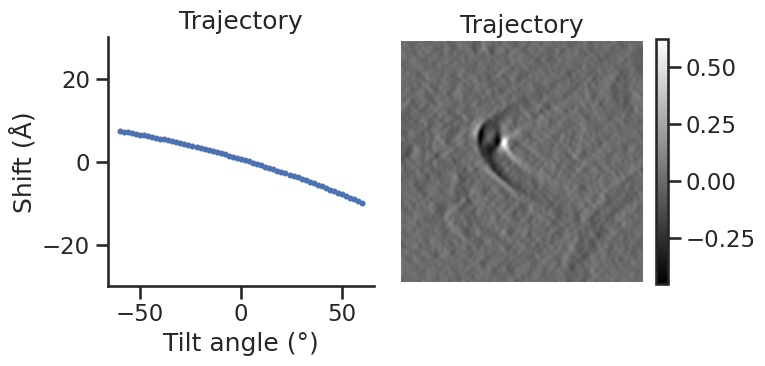

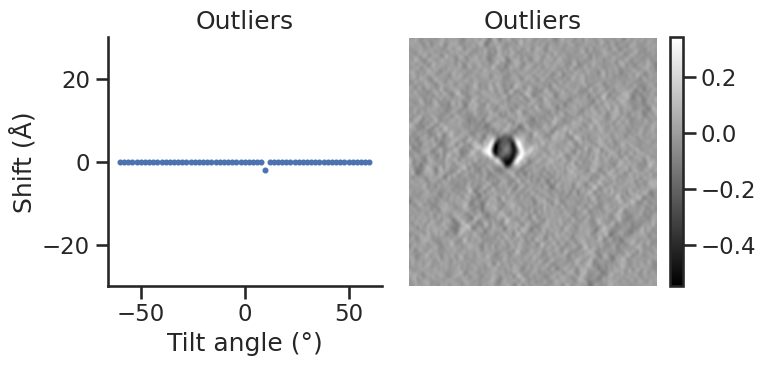

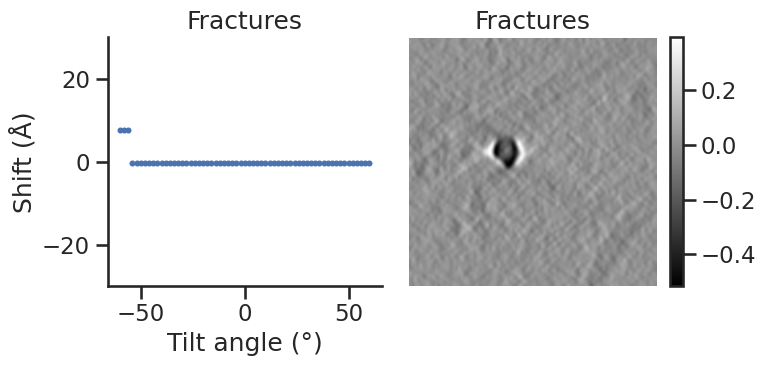

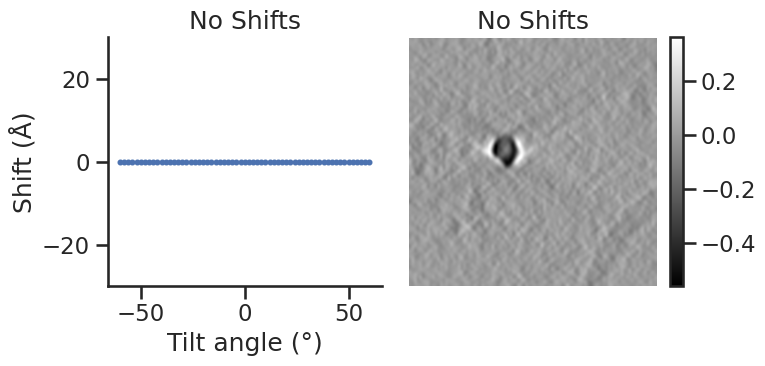

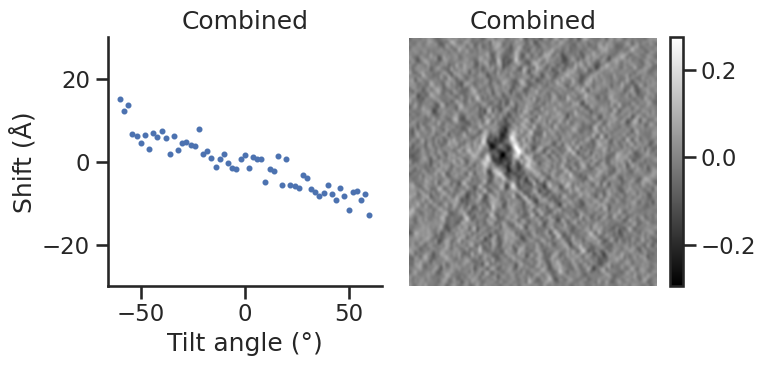

In [10]:
# Create side-by-side plots for each shift type using stored shifts
shift_types = ['Jitter', 'Trajectory', 'Outliers', 'Fractures']

# Get tilt angles for the stored shifts
tilt_angles_actual = tilt_series.angles.cpu().numpy()

for shift_type in shift_types:
    # Create figure with two subplots
    fig, (ax_shift, ax_recon) = plt.subplots(1, 2, figsize=(8, 4))
    
    # Left subplot: Shift pattern (use stored shifts)
    shifts_for_plot = shifts_dict[shift_type].cpu()[:, 0].numpy()
    ax_shift.scatter(tilt_angles_actual, shifts_for_plot, s=8)
    ax_shift.set_ylim(-30, 30)
    ax_shift.set_ylabel('Shift (Å)')
    ax_shift.set_xlabel('Tilt angle (°)')
    ax_shift.set_title(f'{shift_type}')
    sns.despine(ax=ax_shift)
    
    # Right subplot: Reconstruction
    recon = reconstructions[shift_type]
    im = ax_recon.imshow(recon[:, 10].numpy(), cmap='gray', interpolation='spline36')
    ax_recon.set_title(f'{shift_type}')
    ax_recon.axis('off')
    plt.colorbar(im, ax=ax_recon, fraction=0.046)
    
    fig.tight_layout()
    plt.savefig(f'shift_illustration_{shift_type.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for the no-shift baseline
fig, (ax_shift, ax_recon) = plt.subplots(1, 2, figsize=(8, 4))

# Left subplot: No shifts (flat line at 0)
ax_shift.scatter(tilt_angles_actual, np.zeros(len(tilt_angles_actual)), s=8)
ax_shift.set_ylim(-30, 30)
ax_shift.set_ylabel('Shift (Å)')
ax_shift.set_xlabel('Tilt angle (°)')
ax_shift.set_title('No Shifts')
sns.despine(ax=ax_shift)

# Right subplot: Reconstruction
recon = reconstructions['No shifts']
im = ax_recon.imshow(recon[:, 10].numpy(), cmap='gray', interpolation='spline36')
ax_recon.set_title('No Shifts')
ax_recon.axis('off')
plt.colorbar(im, ax=ax_recon, fraction=0.046)

fig.tight_layout()
plt.savefig('shift_illustration_no_shifts.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot for the combined shifts
fig, (ax_shift, ax_recon) = plt.subplots(1, 2, figsize=(8, 4))

# Left subplot: Combined shift pattern (sum of all shifts)
combined_shifts_for_plot = shifts_dict['Combined'].cpu()[:, 0].numpy()
ax_shift.scatter(tilt_angles_actual, combined_shifts_for_plot, s=8)
ax_shift.set_ylim(-30, 30)  # Increased range for combined shifts
ax_shift.set_ylabel('Shift (Å)')
ax_shift.set_xlabel('Tilt angle (°)')
ax_shift.set_title('Combined')
sns.despine(ax=ax_shift)

# Right subplot: Reconstruction
recon = reconstructions['Combined']
im = ax_recon.imshow(recon[:, 10].numpy(), cmap='gray', interpolation='spline36')
ax_recon.set_title('Combined')
ax_recon.axis('off')
plt.colorbar(im, ax=ax_recon, fraction=0.046)

fig.tight_layout()
plt.savefig('shift_illustration_combined.png', dpi=300, bbox_inches='tight')
plt.show()